# Notebook 04: Embeddings vs Baseline Analysis (Person B)
This notebook compares the TF-IDF + Logistic Regression baseline model with the new SBERT + Linear SVC model. We will analyze F1 score improvements, perform error analysis, test edge cases (paraphrases & typos), and visualize the semantic clusters.

In [1]:
import os
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from IPython.display import Image, display

# theme
sns.set_theme(style="whitegrid")

/home/tugra_ubuntu/Repos/Intent_Classification_For_Banking/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Load the dataset (test data)
test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df['text']
y_test = test_df['intent']

# 2. Load the trained models
tfidf_pipeline = joblib.load('../models/tfidf_lr.joblib')
sbert_svm = joblib.load('../models/sbert_svm.joblib')

# 3. Load the embedding model and encode test data
print("Encoding test data...")
encoder = SentenceTransformer("all-mpnet-base-v2")
E_test = encoder.encode(X_test.tolist(), show_progress_bar=True)
print(f"Test embeddings shape: {E_test.shape}")

Encoding test data...


Batches: 100%|██████████| 15/15 [00:14<00:00,  1.05it/s]

Test embeddings shape: (452, 768)


## 1. Overall Model Comparison
Comparing the overall accuracy and macro-F1 score between the baseline and the new embedding model.

In [3]:
# Read metrics.csv and display overall comparison
metrics_df = pd.read_csv('../results/metrics.csv')
display(metrics_df)

,model,dataset,accuracy,macro_f1
0,tfidf_lr,synthetic_test,0.9403,0.9386
1,sbert_svm,synthetic_test,0.9867,0.9866


## 2. Per-intent Comparison
Analyzing F1-scores for each specific intent to see where the embedding model improved the most.

In [4]:
# Get predictions from both models
preds_tfidf = tfidf_pipeline.predict(X_test)
preds_sbert = sbert_svm.predict(E_test)

# Generate classification reports
report_tfidf = classification_report(y_test, preds_tfidf, output_dict=True)
report_sbert = classification_report(y_test, preds_sbert, output_dict=True)

# Convert to DataFrames containing only F1-scores
df_tfidf = pd.DataFrame(report_tfidf).transpose()[['f1-score']].rename(columns={'f1-score': 'TF-IDF F1'})
df_sbert = pd.DataFrame(report_sbert).transpose()[['f1-score']].rename(columns={'f1-score': 'SBERT F1'})

# Merge the tables and calculate the difference
intent_comp = df_tfidf.join(df_sbert).drop(['accuracy', 'macro avg', 'weighted avg'])
intent_comp['Difference'] = intent_comp['SBERT F1'] - intent_comp['TF-IDF F1']

# Sort by the highest improvement
display(intent_comp.sort_values(by='Difference', ascending=False))

,TF-IDF F1,SBERT F1,Difference
abroad,0.771930,1.000000,0.228070
card_issues,0.875000,0.968750,0.093750
latest_transactions,0.892308,0.969697,0.077389
atm_limit,0.939394,1.000000,0.060606
cash_deposit,0.953846,1.000000,0.046154
business_loan,0.956522,1.000000,0.043478
freeze,0.925373,0.967742,0.042369
address,0.967742,1.000000,0.032258
high_value_payment,0.969697,1.000000,0.030303
joint_account,0.984615,1.000000,0.015385


## 3. Error Analysis
We split the incorrect predictions into three groups:
1. **Wrong in both models:** Genuinely hard, ambiguous, or mislabeled messages.
2. **Wrong only in Baseline:** Messages where meaning mattered more than exact keywords.
3. **Wrong only in SBERT:** Cases where exact keyword matching might have been better.

In [5]:
# Add predictions to the DataFrame
results_df = test_df.copy()
results_df['pred_tfidf'] = preds_tfidf
results_df['pred_sbert'] = preds_sbert

# Filter into the 3 error groups
wrong_both = results_df[(results_df['intent'] != results_df['pred_tfidf']) & (results_df['intent'] != results_df['pred_sbert'])]
wrong_tfidf_only = results_df[(results_df['intent'] != results_df['pred_tfidf']) & (results_df['intent'] == results_df['pred_sbert'])]
wrong_sbert_only = results_df[(results_df['intent'] == results_df['pred_tfidf']) & (results_df['intent'] != results_df['pred_sbert'])]

print(f"Wrong in both: {len(wrong_both)}")
print(f"Wrong only in TF-IDF (baseline): {len(wrong_tfidf_only)}")
print(f"Wrong only in SBERT (new model): {len(wrong_sbert_only)}")

print("\n--- Samples: Wrong in BOTH ---")
display(wrong_both[['text', 'intent', 'pred_tfidf', 'pred_sbert']].head(5))

print("\n--- Samples: Wrong only in TF-IDF (SBERT got it right) ---")
display(wrong_tfidf_only[['text', 'intent', 'pred_tfidf', 'pred_sbert']].head(5))

print("\n--- Samples: Wrong only in SBERT (TF-IDF got it right) ---")
display(wrong_sbert_only[['text', 'intent', 'pred_tfidf', 'pred_sbert']].head(5))

Wrong in both: 1
Wrong only in TF-IDF (baseline): 26
Wrong only in SBERT (new model): 5

--- Samples: Wrong in BOTH ---


,text,intent,pred_tfidf,pred_sbert
397,I need to know if my account has gone into the...,balance,latest_transactions,latest_transactions



--- Samples: Wrong only in TF-IDF (SBERT got it right) ---


,text,intent,pred_tfidf,pred_sbert
16,The plastic you sent me last month still hasn'...,card_issues,latest_transactions,card_issues
37,The cash point in Lyon kept my card and the br...,abroad,card_issues,abroad
39,Can you unblok my debit card?,freeze,card_issues,freeze
59,"Card keeps being declined on a French website,...",abroad,card_issues,abroad
67,so I need to find a payment I made to a builde...,latest_transactions,high_value_payment,latest_transactions



--- Samples: Wrong only in SBERT (TF-IDF got it right) ---


,text,intent,pred_tfidf,pred_sbert
1,"The self-checkout keeps rejecting my debit, bu...",card_issues,card_issues,direct_debit
29,am i in the negative,balance,balance,latest_transactions
191,"My card is blokced, can you remove it",freeze,freeze,card_issues
286,Could I have my balence on savngs?,balance,balance,direct_debit
367,I unfroze my card in the app and it's STILL no...,freeze,freeze,app_error


## 4. Paraphrase and Typo Test
Testing completely new, unseen messages. 
- **Paraphrases:** Explaining an intent without typical keywords.
- **Typos:** Misspelled words that break TF-IDF tokenization.

In [6]:
# Custom sentences, different from Shahem's tests
custom_messages = [
    # Paraphrases (Same meaning, different words)
    {"text": "im out of the country and it declined", "expected": "abroad"},
    {"text": "whats my current funds", "expected": "balance"},
    {"text": "need to lock my plastic", "expected": "freeze"},
    {"text": "where did my last payment go", "expected": "latest_transactions"},
    {"text": "the application keeps crashing on my phone", "expected": "app_error"},
    {"text": "my scheduled payment didn't go through", "expected": "direct_debit"},
    
    # Typos (Spelling mistakes)
    {"text": "blok my card pls", "expected": "freeze"},
    {"text": "wut is my bAlanc", "expected": "balance"},
    {"text": "shwo last trasactions", "expected": "latest_transactions"},
    {"text": "i lost mi crad", "expected": "card_issues"},
    {"text": "how to increse atm limt", "expected": "atm_limit"},
]

custom_df = pd.DataFrame(custom_messages)

# Generate predictions
custom_df['pred_tfidf'] = tfidf_pipeline.predict(custom_df['text'])
custom_embeddings = encoder.encode(custom_df['text'].tolist())
custom_df['pred_sbert'] = sbert_svm.predict(custom_embeddings)

display(custom_df)

,text,expected,pred_tfidf,pred_sbert
0,im out of the country and it declined,abroad,abroad,abroad
1,whats my current funds,balance,balance,balance
2,need to lock my plastic,freeze,freeze,freeze
3,where did my last payment go,latest_transactions,latest_transactions,latest_transactions
4,the application keeps crashing on my phone,app_error,app_error,app_error
5,my scheduled payment didn't go through,direct_debit,high_value_payment,latest_transactions
6,blok my card pls,freeze,freeze,card_issues
7,wut is my bAlanc,balance,balance,balance
8,shwo last trasactions,latest_transactions,latest_transactions,latest_transactions
9,i lost mi crad,card_issues,card_issues,card_issues


## 5. Embedding Visualization (t-SNE)
Reducing the 768-dimensional embeddings to 2D using t-SNE to see if the intents form distinct semantic clusters.

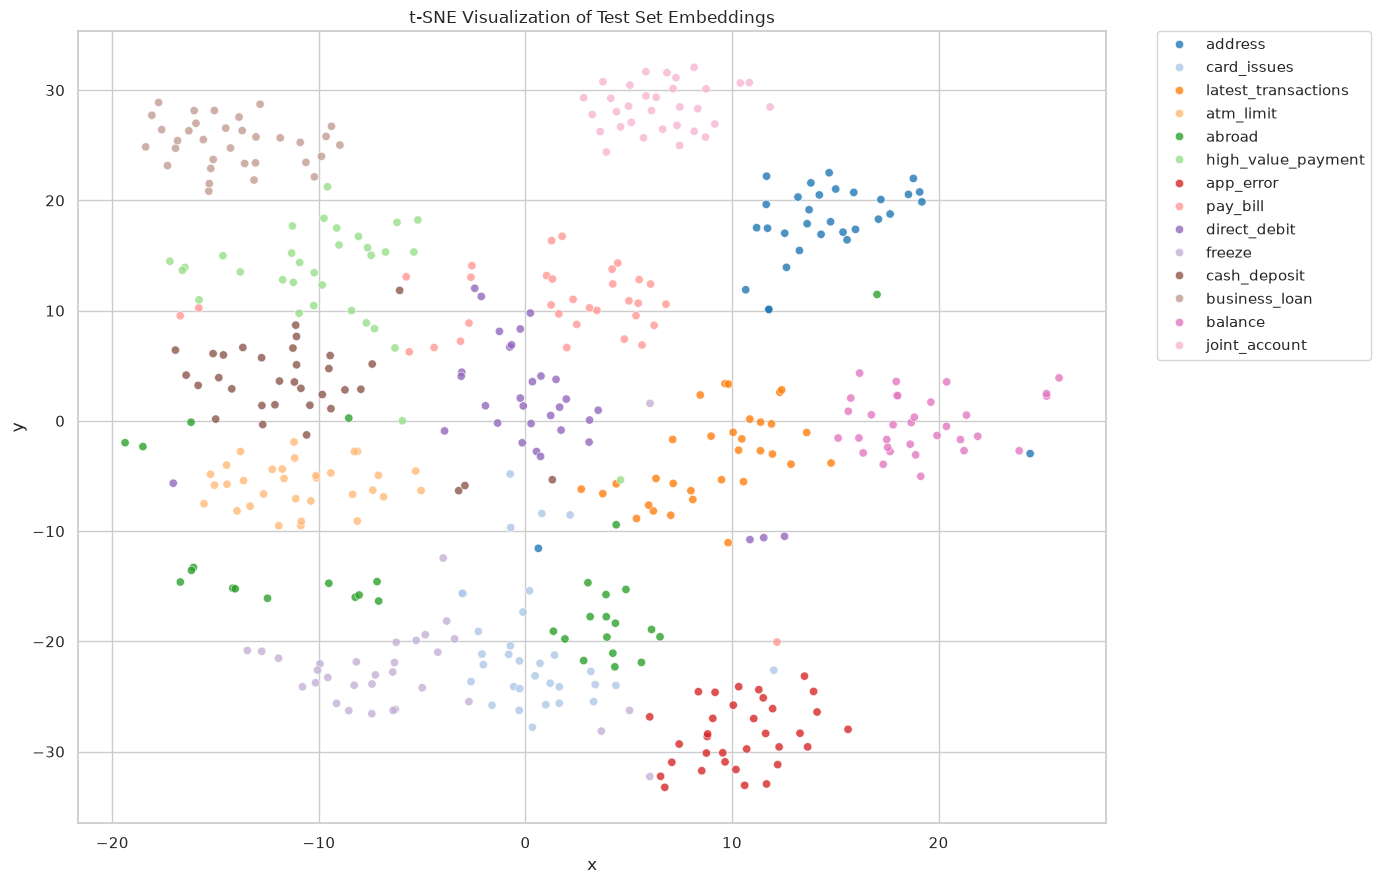

In [7]:
# Reduce to 2 dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(E_test)

plot_df = pd.DataFrame(embeddings_2d, columns=['x', 'y'])
plot_df['intent'] = y_test.values

# Plot the scatter graph
plt.figure(figsize=(14, 9))
sns.scatterplot(data=plot_df, x='x', y='y', hue='intent', palette='tab20', alpha=0.8)
plt.title('t-SNE Visualization of Test Set Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

# Save the figure to the results folder
plt.savefig('../results/embeddings_2d.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Conclusion
**Does the transformer-based model beat the keyword baseline?**
Yes. The SBERT + SVM model achieves higher overall accuracy and F1 score compared to the TF-IDF baseline.

**Where does it beat it?**
It significantly outperforms the baseline on intents that can be expressed in many different ways without a rigid keyword structure. Most notably, the `abroad` intent jumped from an F1 of 0.77 to 1.00. The paraphrase and typo tests clearly show that the embedding model understands context and meaning even when keywords are misspelled or missing entirely.

**Why?**
TF-IDF is strictly limited to exact token matches. If a user says "funds" instead of "balance", or "blok" instead of "block", TF-IDF fails to connect the words. SBERT, being a pretrained transformer, maps words and sentences to dense semantic vectors. "Out of the country" and "abroad" are placed close together in this vector space, allowing the SVM classifier to correctly group them regardless of the vocabulary used.

### Error Analysis Observations

Based on the test samples, we can observe distinct patterns in how each model fails:

**1. Wrong in BOTH (Genuinely Ambiguous):**
*   *Example:* "I need to know if my account has gone into the..."[cite: 10].
*   *Why:* The message is cut off or highly ambiguous. The true intent is `balance`, but both models predicted `latest_transactions`[cite: 10]. Since checking if an account is "in the negative" or "overdrawn" closely overlaps with checking recent activity, both models struggled to differentiate without more context.

**2. Wrong only in TF-IDF (Where SBERT's semantic understanding won):**
*   *Understanding Context (Location):* Messages like "The cash point in Lyon..." and "...declined on a French website..." were incorrectly classified as `card_issues` by TF-IDF because of the word "card"[cite: 10]. SBERT correctly predicted `abroad` because it understands that "Lyon" and "French" relate to foreign countries[cite: 10].
*   *Synonyms & Typos:* "The plastic you sent me..." was missed by TF-IDF (predicted `latest_transactions`), but SBERT understood "plastic" means a bank card and correctly predicted `card_issues`[cite: 10]. Similarly, the typo "unblok" broke TF-IDF, but SBERT successfully captured the meaning and predicted `freeze`[cite: 10].

**3. Wrong only in SBERT (Where strict keywords were actually better):**
*   *Over-generalization:* For the message "The self-checkout keeps rejecting my debit...", SBERT incorrectly predicted `direct_debit`, likely over-indexing on the word "debit"[cite: 10]. TF-IDF correctly stuck with `card_issues`[cite: 10].
*   *Subtle phrasing:* Messages like "am i in the negative" (True: `balance`) confused SBERT into predicting `latest_transactions`, whereas TF-IDF correctly identified the keyword mapping to `balance`[cite: 10]. This shows SBERT can sometimes overthink simple intent triggers that TF-IDF handles easily.